In [3]:
# This notebook implements the following tasks.
# 1. Text processing tokenization, stopword removal, stemming and vocabulary reduction rates.
# 2. Dataset exploration.
# 3. Train of modal validation and test and splited with 80,10,10 ratio

from pathlib import Path
from collections import Counter
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split

if Path("data").exists():
    PROJECT_ROOT = Path(".")
elif Path("..").joinpath("data").exists():
    PROJECT_ROOT = Path("..")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SOURCE_PATH = PROCESSED_DIR / "news_small.csv"

MAX_ROWS_TO_LOAD = 300_000
CHUNK_SIZE = 20_000
ANALYSIS_SAMPLE_ROWS = 50_000
RANDOM_STATE = 42

In [5]:
# NLTK resources for tokenization and stopword removal
# Download only if missing to avoid repeated slow runs.
def ensure_nltk_resource(resource_path: str, download_name: str) -> None:
    try:
        nltk.data.find(resource_path)
        print(f"Already available: {download_name}")
    except LookupError:
        print(f"Downloading: {download_name}")
        nltk.download(download_name, quiet=True)


ensure_nltk_resource("tokenizers/punkt", "punkt")
ensure_nltk_resource("corpora/stopwords", "stopwords")

Already available: punkt
Already available: stopwords


In [6]:
# Simple load from the small processed file
print(f"Loading: {SOURCE_PATH}")
df = pd.read_csv(
    SOURCE_PATH,
    nrows=MAX_ROWS_TO_LOAD,
    engine="python",
    on_bad_lines="skip",
    encoding="utf-8",
    encoding_errors="replace",
)
print(f"Loaded rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
df.head(2)

Loading: ../data/processed/news_small.csv
Loaded rows: 300,000
Columns: 17


,Unnamed: 0,id,domain,type,url,content,scraped_at,inserted_at,updated_at,title,authors,keywords,meta_keywords,meta_description,tags,summary,source
0,0,2,express.co.uk,rumor,https://www.express.co.uk/news/science/738402/...,"Life is an illusion, at least on a quantum lev...",2018-01-25 16:17:44.789555,2018-02-02 01:19:41.756632,2018-02-02 01:19:41.756664,Is life an ILLUSION? Researchers prove 'realit...,Sean Martin,NaN,[''],THE UNIVERSE ceases to exist when we are not l...,NaN,NaN,NaN
1,1,6,barenakedislam.com,hate,http://barenakedislam.com/category/donald-trum...,"Unfortunately, he hasn’t yet attacked her for ...",2018-01-25 16:17:44.789555,2018-02-02 01:19:41.756632,2018-02-02 01:19:41.756664,Donald Trump,"Linda Rivera, Conrad Calvano, Az Gal, Lincoln ...",NaN,[''],NaN,NaN,NaN,NaN


In [7]:
# Keep relevant columns for Part 2 work
keep_cols = ["id", "domain", "type", "title", "content", "url", "scraped_at"]
existing_keep_cols = [c for c in keep_cols if c in df.columns]
df = df[existing_keep_cols].copy()

# Basic cleaning like dropna, drop_duplicates, and strip of content
before = len(df)
df = df.dropna(subset=["content", "type"])
df["content"] = df["content"].astype(str).str.strip()
df = df[df["content"].str.len() > 0]
df = df.drop_duplicates(subset=["content"])
after = len(df)

print(f"Rows before cleaning: {before:,}")
print(f"Rows after cleaning : {after:,}")
print(f"Rows removed        : {before - after:,}")

# Save cleaned dataset
cleaned_path = PROCESSED_DIR / "news_cleaned_part2.csv"
df.to_csv(cleaned_path, index=False)
print(f"Saved cleaned data to: {cleaned_path}")

Rows before cleaning: 300,000
Rows after cleaning : 208,043
Rows removed        : 91,957
Saved cleaned data to: ../data/processed/news_cleaned_part2.csv


In [8]:
# TASK 1: Tokenization, stopword removal, stemming AND vocabulary reduction.

stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()
word_pattern = re.compile(r"^[a-zA-Z]+$")

analysis_df = df.sample(n=min(ANALYSIS_SAMPLE_ROWS, len(df)), random_state=RANDOM_STATE).copy()

raw_vocab = Counter()
nostop_vocab = Counter()
stem_vocab = Counter()

for text in analysis_df["content"]:
    tokens = [t for t in word_tokenize(str(text).lower()) if word_pattern.match(t)]
    raw_vocab.update(tokens)

    no_stop = [t for t in tokens if t not in stop_words]
    nostop_vocab.update(no_stop)

    stemmed = [stemmer.stem(t) for t in no_stop]
    stem_vocab.update(stemmed)

v_raw = len(raw_vocab)
v_nostop = len(nostop_vocab)
v_stem = len(stem_vocab)

task1_stats = pd.DataFrame({
    "stage": ["raw", "after_stopword_removal", "after_stemming"],
    "vocabulary_size": [v_raw, v_nostop, v_stem],
})

task1_reduction = pd.DataFrame({
    "operation": ["stopword_removal", "stemming"],
    "reduction_rate_percent": [
        (v_raw - v_nostop) / v_raw * 100 if v_raw else 0,
        (v_nostop - v_stem) / v_nostop * 100 if v_nostop else 0,
    ],
})

display(task1_stats)
display(task1_reduction)

,stage,vocabulary_size
0,raw,183050
1,after_stopword_removal,182897
2,after_stemming,136841


,operation,reduction_rate_percent
0,stopword_removal,0.083584
1,stemming,25.181386


In [ ]:

# Task 2:  Basic exploration and required text pattern analysis.

url_re = re.compile(r"https?://\S+|www\.\S+")
date_re = re.compile(r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b|\b\d{4}-\d{2}-\d{2}\b")
num_re = re.compile(r"\b\d+(?:\.\d+)?\b")

df["content_len_words"] = df["content"].astype(str).str.split().str.len()
df["num_urls"] = df["content"].astype(str).apply(lambda x: len(url_re.findall(x)))
df["num_dates"] = df["content"].astype(str).apply(lambda x: len(date_re.findall(x)))
df["num_numbers"] = df["content"].astype(str).apply(lambda x: len(num_re.findall(x)))

print("Class distribution:")
display(df["type"].value_counts())

print("Feature summary:")
display(df[["content_len_words", "num_urls", "num_dates", "num_numbers"]].describe())

print("Observation 1: Average article length by class")
display(df.groupby("type")["content_len_words"].mean().sort_values(ascending=False))

print("Observation 2: Average number count by class")
display(df.groupby("type")["num_numbers"].mean().sort_values(ascending=False))

print("Observation 3: Average URL count by class")
display(df.groupby("type")["num_urls"].mean().sort_values(ascending=False))

Class distribution:


type
political     70025
fake          47580
conspiracy    34308
bias          23185
clickbait     10116
junksci        7273
rumor          6474
unknown        5032
unreliable     2340
reliable        844
satire          501
hate            365
Name: count, dtype: int64

Feature summary:


,content_len_words,num_urls,num_dates,num_numbers
count,208043.000000,208043.000000,208043.000000,208043.000000
mean,607.777435,0.485063,0.298626,12.811049
std,834.849021,2.488365,5.422153,43.128107
min,5.000000,0.000000,0.000000,0.000000
25%,159.000000,0.000000,0.000000,2.000000
50%,395.000000,0.000000,0.000000,5.000000
75%,752.000000,0.000000,0.000000,12.000000
max,18809.000000,739.000000,1532.000000,9262.000000


Observation 1: Average article length by class


type
reliable      1182.662322
unknown        904.577305
unreliable     835.214957
bias           707.849946
junksci        686.637014
political      618.602528
fake           599.756116
hate           561.893151
conspiracy     543.721872
clickbait      430.171510
rumor          357.402842
satire         310.271457
Name: content_len_words, dtype: float64

Observation 2: Average number count by class


type
unreliable    24.532906
reliable      18.372038
conspiracy    14.387810
political     13.210296
bias          13.204529
fake          12.813325
unknown       12.211049
hate          10.928767
junksci       10.224529
rumor          7.771548
clickbait      6.548537
satire         3.007984
Name: num_numbers, dtype: float64

Observation 3: Average URL count by class


type
fake          1.353258
junksci       0.764884
unreliable    0.471368
reliable      0.305687
clickbait     0.277580
unknown       0.275040
political     0.214866
conspiracy    0.182640
bias          0.169851
hate          0.101370
satire        0.061876
rumor         0.014211
Name: num_urls, dtype: float64

In [ ]:
# Optional outlier check
q1 = df["content_len_words"].quantile(0.01)
q99 = df["content_len_words"].quantile(0.99)
print(f"Content length outliers: <= {q1:.1f} words or >= {q99:.1f} words")

Content length outliers: <= 19.0 words or >= 3731.6 words


In [10]:
# Top frequent words (before and after preprocessing)
def top_words(counter, n=20):
    return pd.DataFrame(counter.most_common(n), columns=["word", "count"])

print("Top words (raw tokens):")
display(top_words(raw_vocab, 20))

print("Top words (after stopword removal + stemming):")
display(top_words(stem_vocab, 20))

Top words (raw tokens):


,word,count
0,the,1729746
1,to,838444
2,of,836302
3,and,772854
4,a,617665
5,in,557349
6,that,415190
7,is,373855
8,for,282751
9,it,255416


Top words (after stopword removal + stemming):


,word,count
0,one,77845
1,would,68556
2,peopl,67764
3,state,66719
4,time,59595
5,like,56891
6,year,56109
7,said,53218
8,trump,50394
9,new,50137


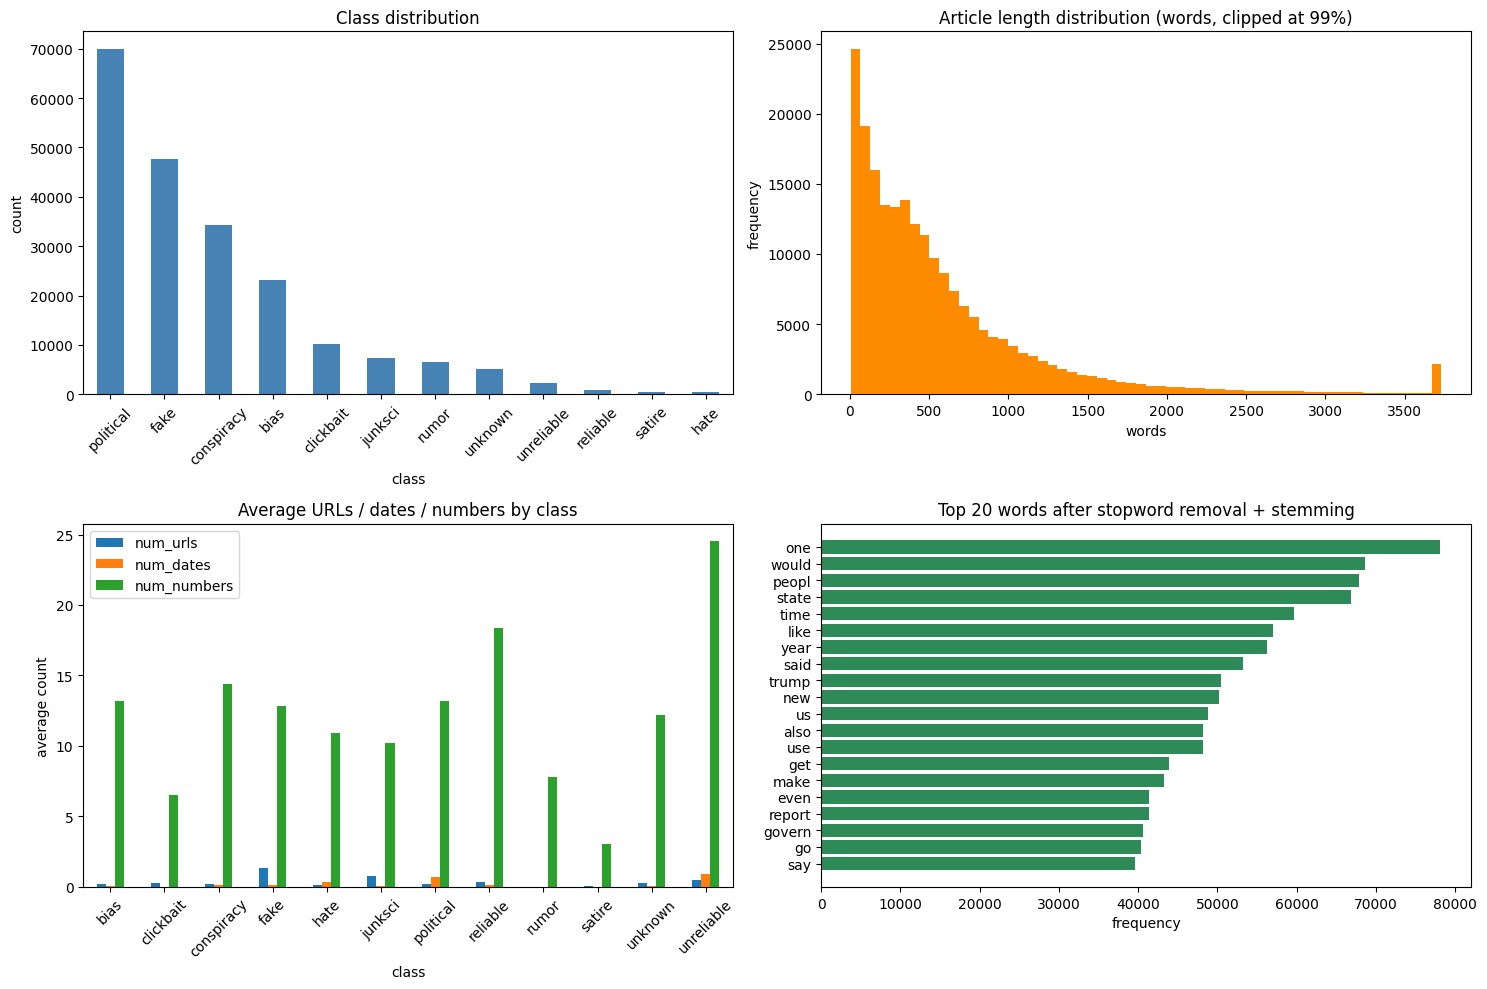

In [ ]:
# plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

df["type"].value_counts().plot(kind="bar", ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Class distribution")
axes[0, 0].set_xlabel("class")
axes[0, 0].set_ylabel("count")
axes[0, 0].tick_params(axis="x", rotation=45)

length_clip = df["content_len_words"].clip(upper=df["content_len_words"].quantile(0.99))
axes[0, 1].hist(length_clip, bins=60, color="darkorange")
axes[0, 1].set_title("Article length distribution (words, clipped at 99%)")
axes[0, 1].set_xlabel("words")
axes[0, 1].set_ylabel("frequency")

signal_means = df.groupby("type")[["num_urls", "num_dates", "num_numbers"]].mean()
signal_means.plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Average URLs / dates / numbers by class")
axes[1, 0].set_xlabel("class")
axes[1, 0].set_ylabel("average count")
axes[1, 0].tick_params(axis="x", rotation=45)

top20_processed = top_words(stem_vocab, 20).sort_values("count")
axes[1, 1].barh(top20_processed["word"], top20_processed["count"], color="seagreen")
axes[1, 1].set_title("Top 20 words after stopword removal + stemming")
axes[1, 1].set_xlabel("frequency")

plt.tight_layout()
plt.show()

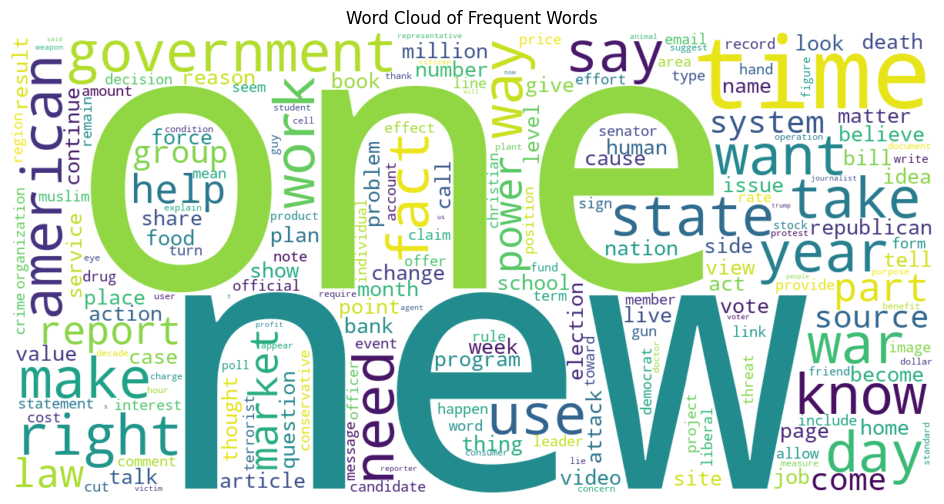

In [11]:
#  Word cloud
try:
    from wordcloud import WordCloud

    wc_text = " ".join(top_words(raw_vocab, 2000)["word"].tolist())
    wc = WordCloud(width=1200, height=600, background_color="white").generate(wc_text)

    plt.figure(figsize=(14, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud of Frequent Words")
    plt.show()
except ImportError:
    print("WordCloud package not installed. Install with: pip install wordcloud")

In [ ]:
#Task 3 splitting of data 80/10/10 ratio

split_df = df.reset_index(drop=True).copy()

train_df, temp_df = train_test_split(
    split_df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=split_df["type"],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temp_df["type"],
)

print(f"Train rows: {len(train_df):,} ({len(train_df)/len(split_df):.1%})")
print(f"Val rows  : {len(val_df):,} ({len(val_df)/len(split_df):.1%})")
print(f"Test rows : {len(test_df):,} ({len(test_df)/len(split_df):.1%})")

train_path = PROCESSED_DIR / "train.csv"
val_path = PROCESSED_DIR / "val.csv"
test_path = PROCESSED_DIR / "test.csv"

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)

print(f"Saved: {train_path}")
print(f"Saved: {val_path}")
print(f"Saved: {test_path}")

label_dist = pd.concat(
    {
        "full": split_df["type"].value_counts(normalize=True),
        "train": train_df["type"].value_counts(normalize=True),
        "val": val_df["type"].value_counts(normalize=True),
        "test": test_df["type"].value_counts(normalize=True),
    },
    axis=1,
).fillna(0)

print("Label distribution by split proportions")
display(label_dist)

Train rows: 166,434 (80.0%)
Val rows  : 20,804 (10.0%)
Test rows : 20,805 (10.0%)


Saved: data/processed/train.csv
Saved: data/processed/val.csv
Saved: data/processed/test.csv
Label distribution by split (proportions):


,full,train,val,test
type,,,,
political,0.336589,0.336590,0.336570,0.336602
fake,0.228703,0.228703,0.228706,0.228695
conspiracy,0.164908,0.164906,0.164920,0.164912
bias,0.111443,0.111444,0.111421,0.111464
clickbait,0.048625,0.048626,0.048596,0.048642
junksci,0.034959,0.034957,0.034945,0.034992
rumor,0.031119,0.031117,0.031148,0.031098
unknown,0.024187,0.024190,0.024178,0.024177
unreliable,0.011248,0.011248,0.011248,0.011247
